## 0. Import thư viện và đọc dữ liệu

### 0.1. Import thư viện

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (f1_score, roc_auc_score, roc_curve, auc as sk_auc,
                              confusion_matrix, accuracy_score)

import xgboost as xgb
import lightgbm as lgb
import shap

RANDOM_STATE = 42

### 0.2. Đọc dữ liệu

Có 2 file dữ liệu:
- **File Training** (Excel): có đầy đủ 2 biến mục tiêu `NHOMNO` và `NHOMNOMOI` để huấn luyện mô hình.
- **File Out-of-sample (OOS)** (CSV): không có nhãn, đây là tập dữ liệu mới cần áp dụng
  mô hình để dự báo.



In [2]:

train_path = "Data_credit_rating_VN.xlsx"
oos_path = "Out_of_sample_data12.csv"

train_raw = pd.read_excel(train_path, sheet_name="saoke_td_ct")
oos_raw = pd.read_csv(oos_path)

print("Kich thuoc tap Training:", train_raw.shape)
print("Kich thuoc tap Out-of-sample:", oos_raw.shape)

Kich thuoc tap Training: (27001, 21)
Kich thuoc tap Out-of-sample: (25000, 18)


In [3]:
train_raw.head()

,MJACCTTYPCD,CURRMIACCTTYPCD,MIACCTTYPDESC,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,...,ID_TIME,DESC_TIME,MJACCTTYPDESC,ORGNBR,PARENTORGNBR,LAISUAT,MUCDICHVAY,NHOMNO,NHOMNOMOI,NHOMNO_TCBS
0,CNS,GC01,CV TG NGAY VND,1,ONG,787127020,851714900.0,851714900.0,VND,28/12/2010,...,1,Vay ngan han,Vay Tieu dung,4,4,0.12,"1900-SX-DV Tu t,dung Gia dinh",1,1,CURR
1,CNS,GC01,CV TG NGAY VND,1,ONG,333388030,142450650.0,142450650.0,VND,40490,...,1,Vay ngan han,Vay Tieu dung,20,19,0.18,1811-CV mua Xe may tra gop,1,1,CURR
2,CNS,GC01,CV TG NGAY VND,1,MR,311014800,357000690.0,357000690.0,VND,27/05/2010,...,1,Vay ngan han,Vay Tieu dung,19,19,0.18,1870-CV TG Sinh hoat Tieu dung,1,1,CURR
3,CNS,TH02,CV TL TH LAI DINH KY VND,1,NaN,35600000,35600000.0,35600000.0,VND,40276,...,2,Vay trung han,Vay Tieu dung,64,4,0.24,1830-CV Sua chua Nha de o,5,5,CURR
4,CNS,GC01,CV TG NGAY VND,1,MR,430174020,88246180.0,88246180.0,VND,23/06/2010,...,1,Vay ngan han,Vay Tieu dung,19,19,0.18,1870-CV TG Sinh hoat Tieu dung,1,1,CURR


## 1. Kiểm tra và xử lý dữ liệu

### 1.1. Kiểm tra dữ liệu


In [4]:
def data_quality_report(df, name):
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isnull().sum(),
        "pct_missing": (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })
    print(f"[{name}] shape = {df.shape}, so dong trung lap hoan toan = {df.duplicated().sum()}")
    return report

data_quality_report(train_raw, "TRAIN")

[TRAIN] shape = (27001, 21), so dong trung lap hoan toan = 44


,dtype,n_missing,pct_missing,n_unique
MJACCTTYPCD,object,0,0.0,3
CURRMIACCTTYPCD,object,0,0.0,31
MIACCTTYPDESC,object,0,0.0,27
LOAIKH,int64,0,0.0,2
SEX,object,1106,4.1,5
BASE_BAL,int64,0,0.0,6163
CURR_BAL,float64,0,0.0,18346
DUNO_QD,float64,0,0.0,18346
CURRENCYCD,object,0,0.0,1
OPEN_DATE,object,0,0.0,2576


In [5]:
data_quality_report(oos_raw, "OOS")

[OOS] shape = (25000, 18), so dong trung lap hoan toan = 178


,dtype,n_missing,pct_missing,n_unique
MJACCTTYPCD,object,0,0.00,3
CURRMIACCTTYPCD,object,0,0.00,34
MIACCTTYPDESC,object,0,0.00,29
LOAIKH,float64,0,0.00,2
SEX,object,1277,5.11,5
BASE_BAL,object,0,0.00,2333
CURR_BAL,object,0,0.00,6032
DUNO_QD,object,0,0.00,6032
CURRENCYCD,object,0,0.00,2
OPEN_DATE,object,0,0.00,844


### 1.2 Chia tập train - test

In [6]:
train_idx, test_idx = train_test_split(
    train_raw.index, test_size=0.2, random_state=RANDOM_STATE,
    stratify=train_raw["NHOMNO"],
)
df_train = train_raw.loc[train_idx].reset_index(drop=True).copy()
df_test = train_raw.loc[test_idx].reset_index(drop=True).copy()
df_oos = oos_raw.copy()   # tap OOS luon duoc giu nguyen thu tu, khong duoc chia

print("Train :", df_train.shape)
print("Test  :", df_test.shape)
print("OOS   :", df_oos.shape)

Train : (21600, 21)
Test  : (5401, 21)
OOS   : (25000, 18)


### 1.3. Xử lý lỗi định dạng & lỗi logic nhập liệu

#### 1.3.1. Lỗi dấu phẩy thập phân (chỉ xảy ra ở OOS)

In [7]:
def fix_locale_decimal(series):
    """Sua loi dau phay thap phan kieu VN ('0,138' -> 0.138)."""
    return pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")

money_cols = ["BASE_BAL", "CURR_BAL", "DUNO_QD", "LAISUAT"]
for df_ in [df_train, df_test, df_oos]:
    for col in money_cols:
        df_[col] = fix_locale_decimal(df_[col])

print("Dtype sau khi sua:")
print(df_oos[money_cols].dtypes)

Dtype sau khi sua:
BASE_BAL    float64
CURR_BAL    float64
DUNO_QD     float64
LAISUAT     float64
dtype: object


#### 1.3.2. Ngày tháng trộn lẫn định dạng (chuỗi dd/mm/yyyy và số serial Excel)

In [8]:
def parse_mixed_date(series):
    """Cot ngay trong file Excel bi luu lan lon giua chuoi va so serial Excel."""
    def _parse_one(x):
        if pd.isna(x):
            return pd.NaT
        if isinstance(x, str):
            return pd.to_datetime(x, format="%d/%m/%Y", errors="coerce")
        try:
            return pd.to_datetime("1899-12-30") + pd.to_timedelta(int(x), unit="D")
        except Exception:
            return pd.NaT
    return series.apply(_parse_one)

for df_ in [df_train, df_test, df_oos]:
    df_["OPEN_DATE_dt"] = parse_mixed_date(df_["OPEN_DATE"])
    df_["NGAYDENHAN_dt"] = parse_mixed_date(df_["NGAYDENHAN"])

df_train[["OPEN_DATE", "OPEN_DATE_dt", "NGAYDENHAN", "NGAYDENHAN_dt"]].head()

,OPEN_DATE,OPEN_DATE_dt,NGAYDENHAN,NGAYDENHAN_dt
0,15/12/2017,2017-12-15,15/12/2020,2020-12-15
1,40824,2011-10-08,41792,2014-06-02
2,43292,2018-07-11,46945,2028-07-11
3,29/09/2017,2017-09-29,29/09/2022,2022-09-29
4,42953,2017-08-06,45144,2023-08-06


#### 1.3.3. Lỗi logic: `OPEN_DATE` sau `NGAYDENHAN` (mở vay sau ngày đáo hạn)

Đây là lỗi dữ liệu (không phải biến động tự nhiên), vì vậy ta không dùng
log-transform (chỉ phù hợp với giá trị đúng nhưng lệch/cực trị) mà gắn cờ + gán lại
bằng kỳ hạn trung vị hợp lệ (tính từ `df_train`).

In [9]:
def compute_tenor_days(df):
    return (df["NGAYDENHAN_dt"] - df["OPEN_DATE_dt"]).dt.days

tenor_train = compute_tenor_days(df_train)
bad_date_train = (tenor_train <= 0) | tenor_train.isna()
print(f"So dong loi logic ngay thang trong TRAIN: {bad_date_train.sum()} / {len(df_train)}")

# Nguong hop le + trung vi CHI hoc tu df_train (tranh leakage)
valid_tenor = tenor_train[~bad_date_train]
tenor_lo, tenor_hi = valid_tenor.quantile([0.01, 0.99])
tenor_median = valid_tenor.median()
print(f"Khoang ky han hop le (1%-99%): {tenor_lo:.0f} - {tenor_hi:.0f} ngay, trung vi = {tenor_median:.0f} ngay")

So dong loi logic ngay thang trong TRAIN: 6 / 21600
Khoang ky han hop le (1%-99%): 365 - 10958 ngay, trung vi = 1461 ngay


In [10]:
def clean_tenor(df, lo, hi, median):
    tenor = compute_tenor_days(df).astype(float)
    bad_flag = (tenor <= 0) | tenor.isna()
    tenor_clipped = tenor.clip(lo, hi)
    tenor_clipped = tenor_clipped.fillna(median)
    tenor_clipped.loc[bad_flag] = median
    df["DATE_ERROR_FLAG"] = bad_flag.astype(int)
    df["TENOR_DAYS"] = tenor_clipped
    df["TENOR_YEARS"] = df["TENOR_DAYS"] / 365.25
    return df

df_train = clean_tenor(df_train, tenor_lo, tenor_hi, tenor_median)
df_test = clean_tenor(df_test, tenor_lo, tenor_hi, tenor_median)
df_oos = clean_tenor(df_oos, tenor_lo, tenor_hi, tenor_median)

for name, d in [("Train", df_train), ("Test", df_test), ("OOS", df_oos)]:
    print(f"{name}: {d['DATE_ERROR_FLAG'].sum()} dong bi loi logic ngay thang ({d['DATE_ERROR_FLAG'].mean()*100:.1f}%)")

Train: 6 dong bi loi logic ngay thang (0.0%)
Test: 1 dong bi loi logic ngay thang (0.0%)
OOS: 90 dong bi loi logic ngay thang (0.4%)


#### 1.3.4. Dòng trùng lặp hoàn toàn

Chỉ loại bỏ ở tập `df_train`/`df_test` (dữ liệu dùng để học mô hình). Không loại bỏ ở
`df_oos` vì đề bài yêu cầu dự báo và xuất kết quả cho toàn bộ dòng của OOS theo đúng
thứ tự ban đầu.

In [11]:
def dedup(df, name):
    n_before = len(df)
    df = df.drop_duplicates(keep="first").reset_index(drop=True)
    print(f"{name}: loai {n_before - len(df)} dong trung lap ({n_before} -> {len(df)})")
    return df

df_train = dedup(df_train, "Train")
df_test = dedup(df_test, "Test")

Train: loai 27 dong trung lap (21600 -> 21573)
Test: loai 5 dong trung lap (5401 -> 5396)


### 1.4. Xử lý dữ liệu thiếu (Missing Data)

Biến duy nhất có giá trị thiếu đáng kể là `SEX` (~4-5%). Kiểm tra kỹ hơn: `SEX` luôn rỗng
khi `LOAIKH=2` (khách hàng doanh nghiệp hợp lý vì doanh nghiệp không có giới tính), nhưng
vẫn còn thiếu ở một số khách hàng cá nhân (`LOAIKH=1`), đây là thiếu dữ liệu thật sự.

Ngoài ra, `SEX` còn dùng **2 chuẩn khác nhau** cho cùng ý nghĩa: tiếng Việt (`ONG`/`BA`) và
tiếng Anh (`MR`/`MRS`/`MS`). Nếu giữ nguyên, mô hình sẽ coi `ONG` và `MR` là 2 hạng mục khác
nhau dù cùng là nam giới → cần gộp về 1 chuẩn trước khi điền giá trị thiếu.

In [12]:
print("SEX thieu theo LOAIKH (Train):")
print(pd.crosstab(df_train["SEX"].isnull(), df_train["LOAIKH"]))

SEX thieu theo LOAIKH (Train):
LOAIKH      1    2
SEX               
False   20692    0
True      555  326


In [13]:
def normalize_sex(series):
    mapping = {"ONG": "M", "MR": "M", "BA": "F", "MRS": "F", "MS": "F"}
    return series.map(mapping)  # gia tri la/thieu -> NaN, dien 'Unknown' o buoc sau

for df_ in [df_train, df_test, df_oos]:
    df_["SEX_CLEAN"] = normalize_sex(df_["SEX"]).fillna("Unknown")
    df_["MUCDICHVAY"] = df_["MUCDICHVAY"].fillna("Unknown")

df_train["SEX_CLEAN"].value_counts()

,count
SEX_CLEAN,
M,13099
F,7593
Unknown,881


### 1.5. Xử lý giá trị ngoại lai (Outliers)

Các biến số dư/hạn mức (`BASE_BAL`, `CURR_BAL`, `DUNO_QD`) có phân phối lệch phải rất mạnh
(một số ít khách hàng có dư nợ lớn gấp hàng trăm lần khách hàng thông thường). Ta minh họa
bằng histogram:

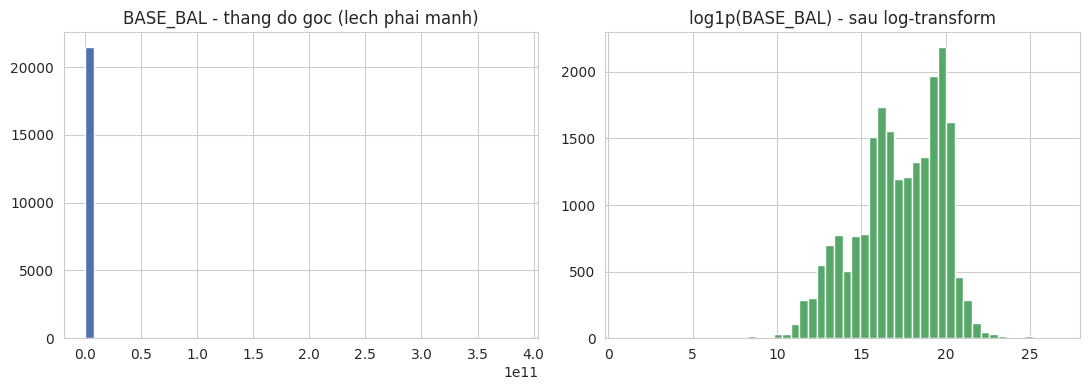

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_train["BASE_BAL"], bins=50, color="#4C72B0")
axes[0].set_title("BASE_BAL - thang do goc (lech phai manh)")
axes[1].hist(np.log1p(df_train["BASE_BAL"]), bins=50, color="#55A868")
axes[1].set_title("log1p(BASE_BAL) - sau log-transform")
plt.tight_layout()
plt.show()

**Lựa chọn phương pháp xử lý ngoại lai: 2 nhóm biến, 2 cách xử lý khác nhau:**

- `BASE_BAL`, `CURR_BAL`, `DUNO_QD`: dùng log-transform (`log1p`) thay vì winsorize/cắt
  ngưỡng (`.clip()`). Lý do: các giá trị lớn ở đây là thật (khách hàng doanh nghiệp/vay
  lớn có tồn tại thật), không phải lỗi nhập liệu. Nếu winsorize (cắt về ngưỡng phần trăm vị)
  sẽ làm mất thông tin phân biệt giữa các khách hàng lớn (ví dụ 2 khách hàng dư nợ 5 tỷ
  và 50 tỷ sẽ bị cắt về cùng 1 giá trị). Log-transform chỉ nén thang đo, vẫn giữ nguyên thứ tự
  và thông tin tương đối giữa các quan sát → không mất thông tin.

- Kỳ hạn vay (`TENOR_YEARS`, Mục 1.3.3): dùng winsorize/gán lại giá trị, KHÔNG dùng
  log-transform. Lý do ngược lại: các giá trị bất thường ở đây (âm, hoặc kỳ hạn 100 năm) là
  lỗi logic nhập liệu thực sự, bản thân giá trị đó SAI (ngày mở vay sau ngày đáo hạn),
  chứ không phải một quan sát cực trị nhưng đúng. Với lỗi dữ liệu thật sự, log-transform
  không sửa được bản chất sai của giá trị nên phải gán lại bằng giá trị hợp lệ.

- `LAISUAT` (lãi suất): kiểm tra thấy nằm trong khoảng hợp lý 0%–40%, không có giá trị
  âm hoặc vượt 100% → không cần xử lý ngoại lai.

In [15]:
for df_ in [df_train, df_test, df_oos]:
    for col in ["BASE_BAL", "CURR_BAL", "DUNO_QD"]:
        df_[f"LOG_{col}"] = np.log1p(df_[col].clip(lower=0))

print("LAISUAT - kiem tra khoang gia tri hop ly:")
print(df_train["LAISUAT"].describe()[["min", "max"]])

LAISUAT - kiem tra khoang gia tri hop ly:
min    0.0
max    0.4
Name: LAISUAT, dtype: float64


### 1.6. Xử lý dữ liệu mất cân bằng (Unbalanced Data)

NHOMNO
1    79.1
2     4.1
3     2.1
4     2.7
5    12.1
Name: proportion, dtype: float64


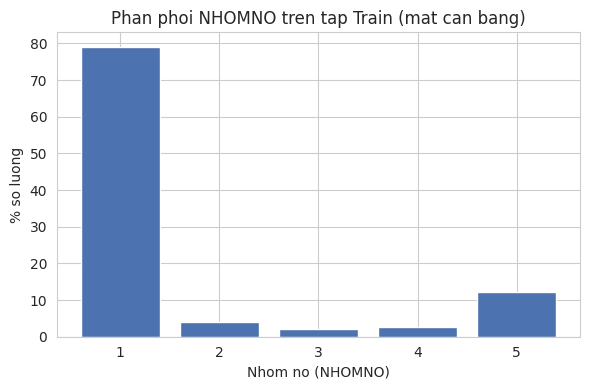

Ty le mat can bang (lop nhieu nhat / lop it nhat) = 38.3 lan


In [16]:
dist = df_train["NHOMNO"].value_counts(normalize=True).sort_index()
print((dist * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dist.index.astype(str), dist.values * 100, color="#4C72B0")
ax.set_xlabel("Nhom no (NHOMNO)")
ax.set_ylabel("% so luong")
ax.set_title("Phan phoi NHOMNO tren tap Train (mat can bang)")
plt.tight_layout()
plt.show()

print(f"Ty le mat can bang (lop nhieu nhat / lop it nhat) = {dist.max()/dist.min():.1f} lan")

Nhóm 1 chiếm ~79% trong khi nhóm 3 chỉ ~2%, mất cân bằng ~38 lần. Nếu huấn luyện trực tiếp,
mô hình sẽ có xu hướng luôn dự báo nhóm 1 để tối đa hoá accuracy tổng thể mà bỏ qua các
nhóm nợ xấu (đúng nhóm cần phát hiện nhất trong bài toán tín dụng).

Cách xử lý được chọn: `class_weight`/`sample_weight = "balanced"` khi huấn luyện, mỗi
quan sát được gán trọng số tỷ lệ nghịch với tần suất của lớp, giúp mô hình "chú ý" hơn đến
các lớp thiểu số mà không cần tạo dữ liệu giả.

Không dùng SMOTE vì dữ liệu có cả biến số và biến hạng mục nhiều chiều sau one-hot; nội
suy tuyến tính giữa các điểm one-hot dễ sinh ra bản ghi phi thực tế

## 2. Feature Engineering & lựa chọn biến

### 2.1. Tạo biến mới

- `UTILIZATION` = `CURR_BAL / BASE_BAL`: tỷ lệ dư nợ hiện tại trên hạn mức gốc. Đây là
  chỉ báo rủi ro tín dụng khi khách hàng dùng gần hết/vượt hạn mức thường có rủi ro
  cao hơn.
- `IS_FX`: khoản vay có phải ngoại tệ không (`CURRENCYCD != VND`).
- `IS_ZERO_RATE`: lãi suất bằng 0 (thường là sản phẩm ưu đãi đặc biệt).
- `MUCDICHVAY_GROUP`: nhóm mục đích vay theo 2 chữ số đầu của mã (gộp ~40 mã chi tiết
  thành nhóm lớn, giảm số chiều).
- `OPEN_YEAR`: năm mở khoản vay (bắt nhịp xu hướng theo thời gian).

In [17]:
def engineer_basic_features(df):
    df["UTILIZATION"] = np.where(df["BASE_BAL"] > 0, df["CURR_BAL"] / df["BASE_BAL"], np.nan)
    df["UTILIZATION"] = df["UTILIZATION"].clip(0, 5).fillna(1.0)
    df["IS_FX"] = (df["CURRENCYCD"] != "VND").astype(int)
    df["IS_ZERO_RATE"] = (df["LAISUAT"] == 0).astype(int)
    df["MUCDICHVAY_GROUP"] = df["MUCDICHVAY"].astype(str).str.extract(r"^(\d{2})")[0].fillna("NA")
    df["OPEN_YEAR"] = df["OPEN_DATE_dt"].dt.year
    return df

df_train = engineer_basic_features(df_train)
df_test = engineer_basic_features(df_test)
df_oos = engineer_basic_features(df_oos)

df_train[["UTILIZATION", "IS_FX", "IS_ZERO_RATE", "MUCDICHVAY_GROUP", "OPEN_YEAR"]].head()

,UTILIZATION,IS_FX,IS_ZERO_RATE,MUCDICHVAY_GROUP,OPEN_YEAR
0,0.988001,0,1,18,2017
1,1.000000,0,0,18,2011
2,1.000000,0,0,18,2018
3,0.500000,0,0,07,2017
4,0.013049,0,1,18,2017


### 2.2. Mã hóa biến hạng mục

- Biến ít hạng mục (`MJACCTTYPCD`, `SEX_CLEAN`, `LOAIKH`, `DESC_TIME`, `MUCDICHVAY_GROUP`):
  dùng One-Hot Encoding trực tiếp trong pipeline mô hình (Mục 3).
- Biến nhiều hạng mục (`ORGNBR` - chi nhánh, `PARENTORGNBR`, `CURRMIACCTTYPCD` - mã sản
  phẩm chi tiết, `MUCDICHVAY` - mục đích vay chi tiết): One-Hot sẽ tạo quá nhiều cột thưa.
  Thay vào đó dùng Frequency Encoding (thay mã bằng tần suất xuất hiện của nó).


In [18]:
high_card_cols = ["ORGNBR", "PARENTORGNBR", "CURRMIACCTTYPCD", "MUCDICHVAY"]
combined = pd.concat([df_train[high_card_cols], df_test[high_card_cols], df_oos[high_card_cols]], axis=0)
freq_maps = {c: combined[c].value_counts(normalize=True) for c in high_card_cols}

for df_ in [df_train, df_test, df_oos]:
    for c in high_card_cols:
        df_[f"{c}_FREQ"] = df_[c].map(freq_maps[c]).fillna(0.0)

df_train[[f"{c}_FREQ" for c in high_card_cols]].head()

,ORGNBR_FREQ,PARENTORGNBR_FREQ,CURRMIACCTTYPCD_FREQ,MUCDICHVAY_FREQ
0,0.018453,0.072774,0.003618,0.307279
1,0.005369,0.043449,0.350401,0.028325
2,0.010987,0.043006,0.096288,0.077931
3,0.009871,0.037368,0.146203,0.039158
4,0.008697,0.023976,0.189074,0.307279


In [19]:
NUMERIC_FEATURES = [
    "LOG_BASE_BAL", "LOG_CURR_BAL", "LOG_DUNO_QD", "LAISUAT", "UTILIZATION",
    "TENOR_YEARS", "OPEN_YEAR", "DATE_ERROR_FLAG", "IS_FX", "IS_ZERO_RATE",
    "ORGNBR_FREQ", "PARENTORGNBR_FREQ", "CURRMIACCTTYPCD_FREQ", "MUCDICHVAY_FREQ",
]
CATEGORICAL_FEATURES = ["MJACCTTYPCD", "SEX_CLEAN", "LOAIKH", "DESC_TIME", "MUCDICHVAY_GROUP"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Tong so bien dau vao: {len(ALL_FEATURES)}")
print(ALL_FEATURES)

Tong so bien dau vao: 19
['LOG_BASE_BAL', 'LOG_CURR_BAL', 'LOG_DUNO_QD', 'LAISUAT', 'UTILIZATION', 'TENOR_YEARS', 'OPEN_YEAR', 'DATE_ERROR_FLAG', 'IS_FX', 'IS_ZERO_RATE', 'ORGNBR_FREQ', 'PARENTORGNBR_FREQ', 'CURRMIACCTTYPCD_FREQ', 'MUCDICHVAY_FREQ', 'MJACCTTYPCD', 'SEX_CLEAN', 'LOAIKH', 'DESC_TIME', 'MUCDICHVAY_GROUP']


### 2.3. Lựa chọn biến (Feature Selection)

Ta dùng 2 phương pháp bổ trợ nhau để đánh giá sức dự báo của từng biến:

1. Mutual Information: đo lượng thông tin chung giữa biến độc lập và `NHOMNO`, không
   giả định quan hệ tuyến tính (phù hợp vì quan hệ giữa các biến và nhóm nợ có thể phi tuyến).
2. WOE/IV (Weight of Evidence / Information Value): đo sức phân tách giữa nhóm "nợ tốt" và "nợ xấu" (ta định nghĩa `BAD = 1` nếu
   `NHOMNO >= 3`, theo chuẩn phân loại nợ của NHNN: nhóm 3-4-5 là dưới tiêu chuẩn/nghi ngờ/có
   khả năng mất vốn).

In [20]:
preprocessor_demo = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
                       ("ohe", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL_FEATURES),
])
X_demo = preprocessor_demo.fit_transform(df_train[ALL_FEATURES])
feat_names_demo = preprocessor_demo.get_feature_names_out()

mi = mutual_info_classif(X_demo, df_train["NHOMNO"], random_state=RANDOM_STATE)
mi_rank = pd.Series(mi, index=feat_names_demo).sort_values(ascending=False)
mi_rank.head(15)

,0
num__CURRMIACCTTYPCD_FREQ,0.325629
num__LAISUAT,0.275553
num__TENOR_YEARS,0.253150
num__UTILIZATION,0.183900
num__MUCDICHVAY_FREQ,0.180942
num__OPEN_YEAR,0.150537
cat__MJACCTTYPCD_CNS,0.120134
num__ORGNBR_FREQ,0.105986
num__LOG_DUNO_QD,0.102115
num__LOG_CURR_BAL,0.100846


In [21]:
def compute_iv(df, feature, bad_flag, n_bins=10):
    x = df[feature]
    tmp = pd.DataFrame({"x": x, "bad": bad_flag.values})
    if pd.api.types.is_numeric_dtype(x) and x.nunique() > n_bins:
        tmp["bin"] = pd.qcut(tmp["x"], q=n_bins, duplicates="drop")
    else:
        tmp["bin"] = tmp["x"]
    grp = tmp.groupby("bin", observed=True)["bad"].agg(["count", "sum"])
    grp.columns = ["total", "n_bad"]
    grp["n_good"] = grp["total"] - grp["n_bad"]
    tb, tg = grp["n_bad"].sum(), grp["n_good"].sum()
    pct_bad = (grp["n_bad"] + 0.5) / (tb + 0.5 * len(grp))
    pct_good = (grp["n_good"] + 0.5) / (tg + 0.5 * len(grp))
    woe = np.log(pct_good / pct_bad)
    iv = ((pct_good - pct_bad) * woe).sum()
    return iv

bad_flag = (df_train["NHOMNO"] >= 3).astype(int)
iv_table = pd.Series({f: compute_iv(df_train, f, bad_flag) for f in ALL_FEATURES}).sort_values(ascending=False)
iv_table.head(15)

,0
CURRMIACCTTYPCD_FREQ,3.025635
TENOR_YEARS,2.724890
UTILIZATION,1.912874
MUCDICHVAY_FREQ,1.542443
MJACCTTYPCD,1.531359
LAISUAT,1.343737
MUCDICHVAY_GROUP,1.304794
OPEN_YEAR,1.276350
IS_ZERO_RATE,1.070941
LOG_BASE_BAL,0.764277


**Nhận xét**: cả 2 phương pháp đều đồng thuận nhóm biến có sức dự báo mạnh nhất là
`CURRMIACCTTYPCD_FREQ`, `LAISUAT`, `TENOR_YEARS`, `UTILIZATION`, `MUCDICHVAY_FREQ`, `OPEN_YEAR`,
`MJACCTTYPCD`. Giá trị IV ở đây khá cao so với ngưỡng tham khảo thông thường (IV>0.3 = "mạnh"),
điều này một phần do dữ liệu mất cân bằng nặng (Mục 1.6) khiến một số bin có rất ít quan sát ở
nhóm thiểu số, cần diễn giải các con số IV một cách thận trọng, không tuyệt đối hoá.

Ta giữ lại toàn bộ 19 biến đã xây dựng (không loại thêm) vì số lượng biến còn khá gọn và
các mô hình cây/boosting ở Mục 4 tự động hạ trọng số các biến ít hữu ích.

**Kiểm tra đa cộng tuyến** (quan trọng với các mô hình tuyến tính như Logistic/LDA/QDA ở Mục 3):

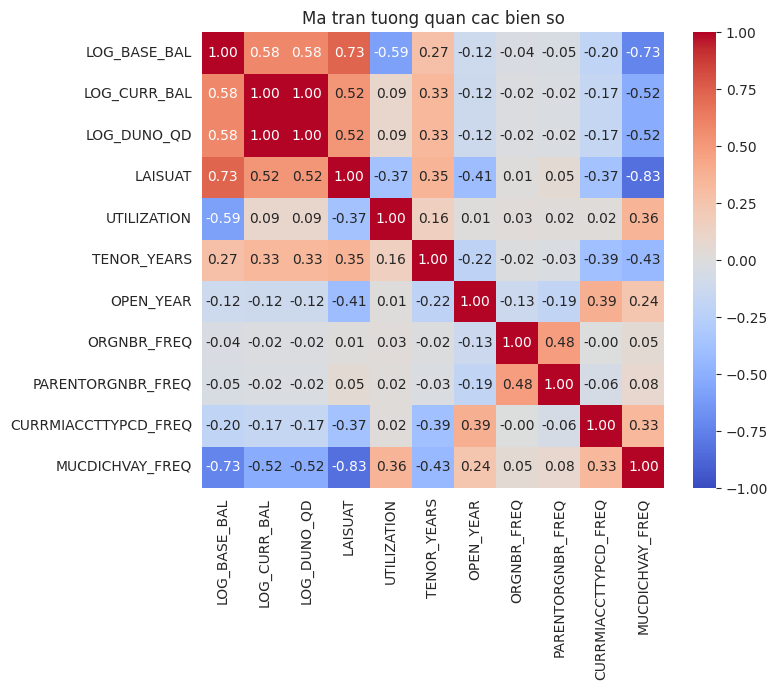

In [22]:
corr_cols = ["LOG_BASE_BAL", "LOG_CURR_BAL", "LOG_DUNO_QD", "LAISUAT", "UTILIZATION",
             "TENOR_YEARS", "OPEN_YEAR", "ORGNBR_FREQ", "PARENTORGNBR_FREQ",
             "CURRMIACCTTYPCD_FREQ", "MUCDICHVAY_FREQ"]
corr = df_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Ma tran tuong quan cac bien so")
plt.tight_layout()
plt.show()

`LOG_CURR_BAL` và `LOG_DUNO_QD` tương quan gần như tuyệt đối (r≈1.0) vì `DUNO_QD = CURR_BAL`
đối với mọi khoản vay VND (đã phát hiện từ EDA ban đầu: `DUNO_QD` là dư nợ *quy đổi* sang
VND, chỉ khác `CURR_BAL` khi khoản vay là ngoại tệ). Ta loại `LOG_DUNO_QD` khỏi danh sách biến
số dùng cho các mô hình tuyến tính (Logistic/LDA/QDA) để tránh đa cộng tuyến, nhưng vẫn giữ
cho các mô hình cây (không bị ảnh hưởng bởi đa cộng tuyến).

In [23]:
NUMERIC_FEATURES_LINEAR = [c for c in NUMERIC_FEATURES if c != "LOG_DUNO_QD"]
print("Bien so dung cho mo hinh tuyen tinh (Logistic/LDA/QDA):", len(NUMERIC_FEATURES_LINEAR))

Bien so dung cho mo hinh tuyen tinh (Logistic/LDA/QDA): 13


### Chuẩn bị chung: tiền xử lý (pipeline) và hàm đánh giá

Ta xây 2 bộ tiền xử lý:
- `preprocess_tree`: dùng đủ 19 biến cho các mô hình cây/boosting (Mục 3.2, 4.x) vì
  chúng không bị ảnh hưởng bởi đa cộng tuyến hay thang đo.
- `preprocess_linear`: bỏ `LOG_DUNO_QD` (đa cộng tuyến với `LOG_CURR_BAL`) — cho các mô
  hình tuyến tính/thống kê (Logistic, LDA, QDA).

Cả 2 đều: điền giá trị thiếu (median cho biến số, "Unknown" cho biến hạng mục), chuẩn hoá
biến số (`StandardScaler`) và One-Hot Encoding cho biến hạng mục. Các bước này chỉ được
`fit` trên `df_train`.

Target dùng xuyên suốt Mục 3-6 là `NHOMNO` (biến chính): Mục 7 sẽ áp dụng lại cùng
cách tiếp cận cho `NHOMNOMOI`.

In [24]:
def make_preprocessor(numeric_cols):
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
                           ("ohe", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL_FEATURES),
    ])

preprocess_tree = make_preprocessor(NUMERIC_FEATURES)
Xtr_tree = preprocess_tree.fit_transform(df_train[ALL_FEATURES])
Xte_tree = preprocess_tree.transform(df_test[ALL_FEATURES])

preprocess_linear = make_preprocessor(NUMERIC_FEATURES_LINEAR)
linear_features = NUMERIC_FEATURES_LINEAR + CATEGORICAL_FEATURES
Xtr_lin = preprocess_linear.fit_transform(df_train[linear_features])
Xte_lin = preprocess_linear.transform(df_test[linear_features])

y_tr = df_train["NHOMNO"]
y_te = df_test["NHOMNO"]
classes_ = sorted(df_train["NHOMNO"].unique())
sample_weight_tr = compute_sample_weight("balanced", y_tr)   # xu ly mat can bang (Muc 1.6)

print("Xtr_tree:", Xtr_tree.shape, " Xtr_lin:", Xtr_lin.shape)

Xtr_tree: (21573, 44)  Xtr_lin: (21573, 43)


In [25]:
def evaluate_model(name, y_true, y_pred, proba, classes):
    f1_macro = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro", labels=classes)
    gini = 2 * auc - 1
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    print(f"--- {name} ---")
    print(f"Accuracy = {acc:.4f}  |  F1-macro = {f1_macro:.4f}  |  AUC = {auc:.4f}  |  Gini = {gini:.4f}")

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel("Du bao")
    ax.set_ylabel("Thuc te")
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": acc, "f1_macro": f1_macro, "auc": auc, "gini": gini}

results = []   # se gom ket qua cua ca 6 mo hinh de so sanh o Muc 5

## 3. Mô hình truyền thống

Nhóm mô hình thống kê/tham số cổ điển, được dùng phổ biến trong chấm điểm tín dụng vì
tính đơn giản, ổn định và dễ diễn giải (giải thích được với bộ phận rủi ro/kiểm toán):

- **3.1 Logistic Regression**: mô hình hồi quy tuyến tính cho phân loại, hệ số hồi quy có
  thể diễn giải trực tiếp qua odds ratio.
- **3.2 Decision Tree**: cây quyết định đơn, luật quyết định trực quan (nếu X thì Y),
  dễ giải thích cho người không chuyên kỹ thuật.
- **3.3 LDA / QDA**: phương pháp thống kê cổ điển dựa trên giả định phân phối Gaussian
  của các biến trong từng lớp.

### 3.1. Logistic Regression

--- Logistic Regression ---
Accuracy = 0.6116  |  F1-macro = 0.4106  |  AUC = 0.8249  |  Gini = 0.6498


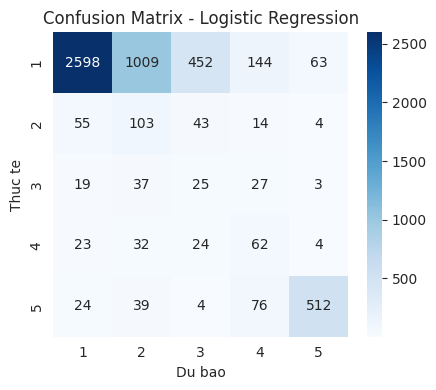

In [26]:
logreg = LogisticRegression(solver="lbfgs", max_iter=2000, class_weight="balanced",
                             C=1.0, random_state=RANDOM_STATE)
logreg.fit(Xtr_lin, y_tr)   # class_weight="balanced" da xu ly mat can bang, khong truyen them sample_weight

results.append(evaluate_model("Logistic Regression", y_te, logreg.predict(Xte_lin),
                               logreg.predict_proba(Xte_lin), classes_))

### 3.2. Decision Tree

Giới hạn `max_depth=6` để tránh overfit (cây không giới hạn độ sâu sẽ học thuộc lòng dữ
liệu train, đặc biệt nguy hiểm khi các lớp thiểu số chỉ có vài trăm quan sát).

--- Decision Tree ---
Accuracy = 0.6420  |  F1-macro = 0.4929  |  AUC = 0.9012  |  Gini = 0.8024


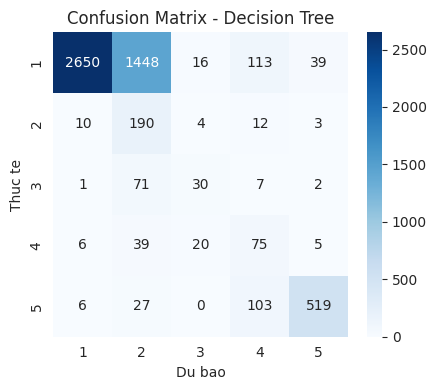

In [27]:
tree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight="balanced",
                               random_state=RANDOM_STATE)
tree.fit(Xtr_tree, y_tr)   # class_weight="balanced" da xu ly mat can bang, khong truyen them sample_weight

results.append(evaluate_model("Decision Tree", y_te, tree.predict(Xte_tree),
                               tree.predict_proba(Xte_tree), classes_))

### 3.3. LDA / QDA

- **LDA** giả định các lớp có chung 1 ma trận hiệp phương sai, ranh giới phân loại là
  đường/mặt phẳng tuyến tính. Ổn định hơn khi dữ liệu ít.
- **QDA** cho phép mỗi lớp có ma trận hiệp phương sai riêng, linh hoạt hơn (ranh giới cong)
  nhưng cần ước lượng nhiều tham số hơn.

--- LDA ---
Accuracy = 0.6225  |  F1-macro = 0.3818  |  AUC = 0.7769  |  Gini = 0.5539


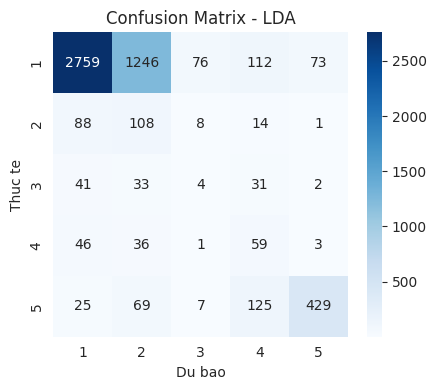

In [28]:
priors_balanced = np.ones(len(classes_)) / len(classes_)

lda = LinearDiscriminantAnalysis(priors=priors_balanced)
lda.fit(Xtr_lin.toarray() if hasattr(Xtr_lin, "toarray") else Xtr_lin, y_tr)

results.append(evaluate_model("LDA", y_te,
                               lda.predict(Xte_lin.toarray() if hasattr(Xte_lin, "toarray") else Xte_lin),
                               lda.predict_proba(Xte_lin.toarray() if hasattr(Xte_lin, "toarray") else Xte_lin),
                               classes_))

--- QDA ---
Accuracy = 0.5096  |  F1-macro = 0.3713  |  AUC = 0.8021  |  Gini = 0.6042


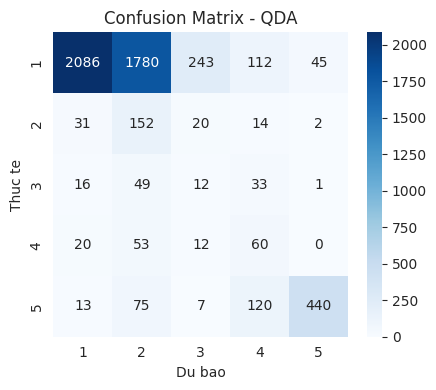

In [29]:
qda = QuadraticDiscriminantAnalysis(reg_param=0.3, priors=priors_balanced)
Xtr_lin_dense = Xtr_lin.toarray() if hasattr(Xtr_lin, "toarray") else Xtr_lin
Xte_lin_dense = Xte_lin.toarray() if hasattr(Xte_lin, "toarray") else Xte_lin
qda.fit(Xtr_lin_dense, y_tr)

results.append(evaluate_model("QDA", y_te, qda.predict(Xte_lin_dense),
                               qda.predict_proba(Xte_lin_dense), classes_))

## 4. Mô hình phi truyền thống

Nhóm mô hình học máy hiện đại (ensemble), thường cho độ chính xác cao hơn nhờ nắm bắt được
quan hệ phi tuyến và tương tác phức tạp giữa các biến, đánh đổi bằng việc khó diễn giải
trực tiếp hơn (cần thêm công cụ như SHAP ở Mục 8):

- **4.1 XGBoost**: gradient boosting: xây tuần tự nhiều cây, mỗi cây sau học để sửa lỗi
  của các cây trước.
- **4.2 LightGBM**: cùng họ gradient boosting với XGBoost nhưng dùng chiến lược mọc cây
  theo lá (leaf-wise) thay vì theo tầng (level-wise), thường huấn luyện nhanh hơn với dữ
  liệu lớn.
- **4.3 Random Forest** bagging: xây nhiều cây **độc lập** trên các mẫu con ngẫu nhiên rồi
  lấy trung bình, giảm phương sai. Dùng làm đối chứng cho 2 mô hình boosting ở trên (boosting
  giảm bias tuần tự, bagging giảm variance song song).

### 4.1. XGBoost

--- XGBoost ---
Accuracy = 0.7845  |  F1-macro = 0.5417  |  AUC = 0.9238  |  Gini = 0.8476


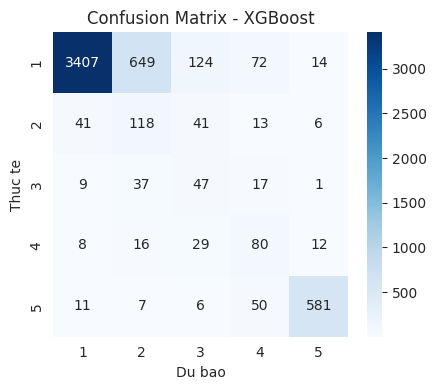

In [30]:
y_tr_0 = y_tr - 1   # xgboost/lightgbm can nhan lop bat dau tu 0
y_te_0 = y_te - 1

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(classes_),
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_model.fit(Xtr_tree, y_tr_0, sample_weight=sample_weight_tr)

results.append(evaluate_model("XGBoost", y_te, xgb_model.predict(Xte_tree) + 1,
                               xgb_model.predict_proba(Xte_tree), classes_))

### 4.2. LightGBM

--- LightGBM ---
Accuracy = 0.8067  |  F1-macro = 0.5494  |  AUC = 0.9244  |  Gini = 0.8488


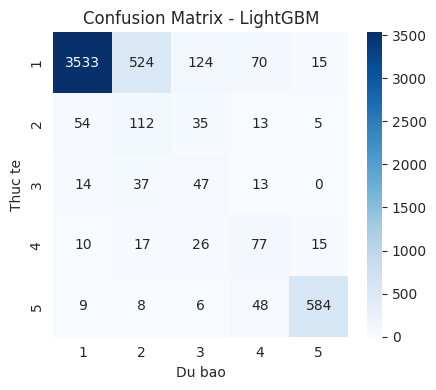

In [31]:
lgb_model = lgb.LGBMClassifier(
    objective="multiclass", num_class=len(classes_),
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgb_model.fit(Xtr_tree, y_tr_0, sample_weight=sample_weight_tr)

results.append(evaluate_model("LightGBM", y_te, lgb_model.predict(Xte_tree) + 1,
                               lgb_model.predict_proba(Xte_tree), classes_))

### 4.3. Random Forest

--- Random Forest ---
Accuracy = 0.6707  |  F1-macro = 0.5095  |  AUC = 0.9037  |  Gini = 0.8073


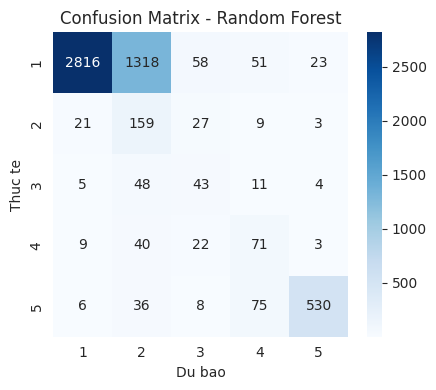

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=10,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_model.fit(Xtr_tree, y_tr)

results.append(evaluate_model("Random Forest", y_te, rf_model.predict(Xte_tree),
                               rf_model.predict_proba(Xte_tree), classes_))

## 5. So sánh hiệu suất mô hình

Các chỉ số dùng để so sánh (đo trên tập **test**, có nhãn thật):

- **Accuracy**: tỷ lệ dự báo đúng tổng thể: dễ hiểu nhưng **không đáng tin** khi dữ liệu
  mất cân bằng (một mô hình luôn đoán nhóm 1 vẫn đạt accuracy ~79%).
- **F1-macro**: trung bình cộng F1-score của cả 5 nhóm (không theo trọng số) → phản ánh
  đúng khả năng phát hiện **cả các nhóm nợ thiểu số**, phù hợp làm chỉ số chính cho bài
  toán này.
- **AUC (One-vs-Rest, macro)**: diện tích dưới đường ROC, đo khả năng phân tách giữa các
  lớp bất kể ngưỡng phân loại.
- **Gini = 2×AUC − 1**: chỉ số quen thuộc trong ngành ngân hàng/chấm điểm tín dụng, cùng ý
  nghĩa với AUC nhưng thang đo quen thuộc hơn với bộ phận rủi ro (0 = ngẫu nhiên, 1 = hoàn hảo).
- **Confusion Matrix** (đã vẽ ở từng mô hình tại Mục 3–4): cho biết mô hình nhầm lẫn cụ thể
  giữa các nhóm nợ nào, quan trọng hơn accuracy vì trong tín dụng, nhầm nhóm 1↔2 ít nghiêm
  trọng hơn nhiều so với nhầm nhóm 1↔5.

In [33]:
summary = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
summary

,model,accuracy,f1_macro,auc,gini
0,LightGBM,0.806709,0.549439,0.924423,0.848845
1,XGBoost,0.784470,0.541682,0.923808,0.847616
2,Random Forest,0.670682,0.509530,0.903656,0.807311
3,Decision Tree,0.641957,0.492853,0.901183,0.802365
4,Logistic Regression,0.611564,0.410601,0.824904,0.649808
5,LDA,0.622498,0.381834,0.776949,0.553897
6,QDA,0.509637,0.371263,0.802118,0.604236


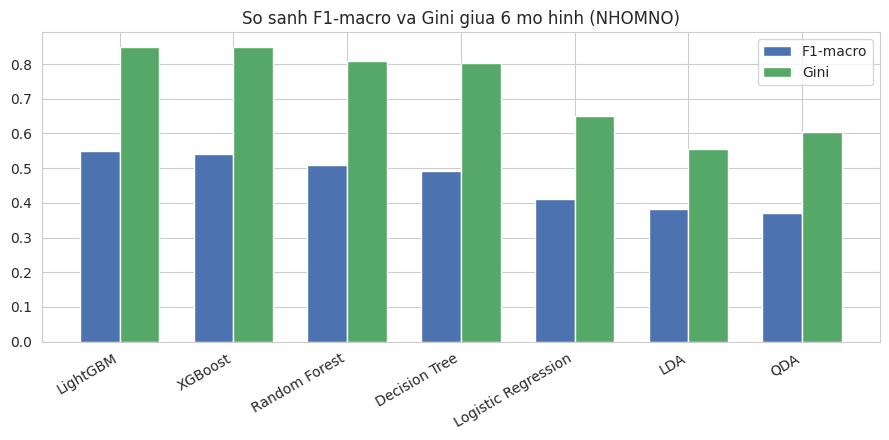

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary["f1_macro"], width, label="F1-macro", color="#4C72B0")
ax.bar(x + width/2, summary["gini"], width, label="Gini", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(summary["model"], rotation=30, ha="right")
ax.set_title("So sanh F1-macro va Gini giua 6 mo hinh (NHOMNO)")
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét chung**:
- Nhóm mô hình **phi truyền thống** (XGBoost/LightGBM/Random Forest) vượt trội nhóm truyền
  thống ở cả F1-macro lẫn Gini — dữ liệu có tương tác phi tuyến giữa loại sản phẩm/kỳ hạn/
  lãi suất mà các mô hình tuyến tính (Logistic/LDA) khó nắm bắt hết.
- **QDA** thường yếu nhất trong nhóm truyền thống do vấn đề ước lượng hiệp phương sai đã nêu
  ở Mục 3.3 (dù đã regularize).
- Mô hình truyền thống tốt nhất và phi truyền thống tốt nhất sẽ được chọn để tinh chỉnh
  siêu tham số ở Mục 6.

In [35]:
best_traditional = summary[summary["model"].isin(["Logistic Regression", "Decision Tree", "LDA", "QDA"])].iloc[0]
best_nontraditional = summary[summary["model"].isin(["XGBoost", "LightGBM", "Random Forest"])].iloc[0]
print("Mo hinh truyen thong tot nhat    :", best_traditional["model"], f"(F1-macro={best_traditional['f1_macro']:.4f})")
print("Mo hinh phi truyen thong tot nhat:", best_nontraditional["model"], f"(F1-macro={best_nontraditional['f1_macro']:.4f})")

Mo hinh truyen thong tot nhat    : Decision Tree (F1-macro=0.4929)
Mo hinh phi truyen thong tot nhat: LightGBM (F1-macro=0.5494)


## 6. Tinh chỉnh siêu tham số (Hyperparameter Tuning)

Ta dùng `RandomizedSearchCV` (3-fold, tối ưu theo F1-macro) để tinh chỉnh **mô hình truyền
thống tốt nhất** và **mô hình phi truyền thống tốt nhất** vừa chọn ở Mục 5.

**Nguyên tắc**: sau khi tuning, ta **so sánh lại** hiệu suất trên tập test, chỉ
chấp nhận bộ tham số mới nếu nó thực sự cải thiện F1-macro. RandomizedSearchCV tối ưu theo
điểm cross-validation nội bộ, không đảm bảo luôn tốt hơn trên tập test độc lập (có thể do
phương sai giữa các fold hoặc không gian tìm kiếm chưa phù hợp) — nếu không tốt hơn, ta giữ
lại mô hình baseline.

### 6.1. Tinh chỉnh Logistic Regression

**Siêu tham số chính**: `C` (nghịch đảo cường độ regularization L2 - C nhỏ → phạt mạnh hệ
số → mô hình đơn giản hơn, tránh overfit; C lớn → gần với hồi quy không phạt).

Best params: {'C': 3}
--- Logistic Regression (tuned) ---
Accuracy = 0.6119  |  F1-macro = 0.4103  |  AUC = 0.8250  |  Gini = 0.6500


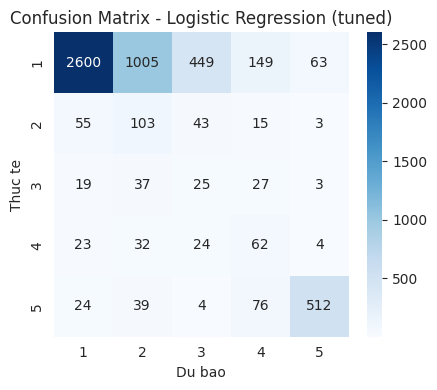

In [36]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

logreg_search = RandomizedSearchCV(
    LogisticRegression(solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions={"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    n_iter=7, scoring="f1_macro", cv=cv3, random_state=RANDOM_STATE, n_jobs=-1,
)
logreg_search.fit(Xtr_lin, y_tr)   # class_weight="balanced" da xu ly mat can bang
print("Best params:", logreg_search.best_params_)

logreg_tuned = logreg_search.best_estimator_
res_logreg_tuned = evaluate_model("Logistic Regression (tuned)", y_te, logreg_tuned.predict(Xte_lin),
                                   logreg_tuned.predict_proba(Xte_lin), classes_)

In [37]:
f1_before = [r for r in results if r["model"] == "Logistic Regression"][0]["f1_macro"]
f1_after = res_logreg_tuned["f1_macro"]
print(f"F1-macro truoc tuning: {f1_before:.4f}  ->  sau tuning: {f1_after:.4f}  "
      f"({'CAI THIEN' if f1_after > f1_before else 'KHONG cai thien, giu baseline'})")

F1-macro truoc tuning: 0.4106  ->  sau tuning: 0.4103  (KHONG cai thien, giu baseline)


### 6.2. Tinh chỉnh XGBoost

**Các siêu tham số được tinh chỉnh**:
- `n_estimators`: số cây boosting.
- `max_depth`: độ sâu tối đa mỗi cây, kiểm soát độ phức tạp/overfit.
- `learning_rate`: tốc độ học, nhỏ hơn thường cần nhiều cây hơn nhưng ổn định hơn.
- `subsample`, `colsample_bytree`: tỷ lệ mẫu/biến dùng ngẫu nhiên mỗi cây, giảm overfit,
  tăng đa dạng giữa các cây (tương tự ý tưởng của Random Forest).
- `min_child_weight`: số lượng mẫu tối thiểu (theo trọng số) để tách 1 node, giá trị lớn
  hơn giúp cây thận trọng hơn khi tách các nhóm dữ liệu ít quan sát.

Best params: {'subsample': 1.0, 'n_estimators': 350, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
--- XGBoost (tuned) ---
Accuracy = 0.8860  |  F1-macro = 0.5663  |  AUC = 0.9264  |  Gini = 0.8529


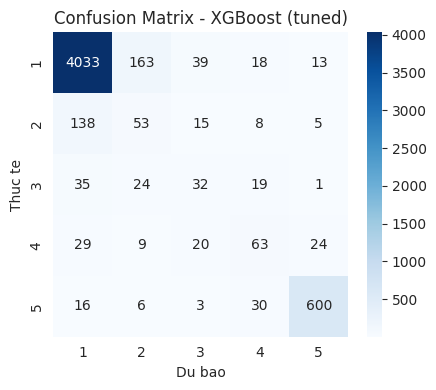

In [38]:
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(objective="multi:softprob", num_class=len(classes_),
                       eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions={
        "n_estimators": [150, 250, 350],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    },
    n_iter=15, scoring="f1_macro", cv=cv3, random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(Xtr_tree, y_tr_0, sample_weight=sample_weight_tr)
print("Best params:", xgb_search.best_params_)

xgb_tuned = xgb_search.best_estimator_
res_xgb_tuned = evaluate_model("XGBoost (tuned)", y_te, xgb_tuned.predict(Xte_tree) + 1,
                                xgb_tuned.predict_proba(Xte_tree), classes_)

In [39]:
f1_before = [r for r in results if r["model"] == "XGBoost"][0]["f1_macro"]
f1_after = res_xgb_tuned["f1_macro"]
print(f"F1-macro truoc tuning: {f1_before:.4f}  ->  sau tuning: {f1_after:.4f}  "
      f"({'CAI THIEN' if f1_after > f1_before else 'KHONG cai thien, giu baseline'})")

# Chon bo tham so cuoi cung dua tren so sanh thuc te tren tap test (khong mac dinh tin RandomizedSearchCV)
FINAL_XGB_PARAMS = xgb_search.best_params_ if f1_after > f1_before else dict(
    n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.9, colsample_bytree=0.9)
print("\n-> Bo tham so XGBoost duoc chon de dung cho Muc 7:", FINAL_XGB_PARAMS)

F1-macro truoc tuning: 0.5417  ->  sau tuning: 0.5663  (CAI THIEN)

-> Bo tham so XGBoost duoc chon de dung cho Muc 7: {'subsample': 1.0, 'n_estimators': 350, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


**Giải thích kết quả**: nếu tuning cải thiện F1-macro, thường là do bộ tham số mặc định ban
đầu chưa tối ưu độ sâu/tốc độ học cho đặc thù dữ liệu mất cân bằng này. Ngược lại, nếu tuning
không cải thiện (hoặc làm giảm hiệu suất trên tập test), nguyên nhân thường là
`RandomizedSearchCV` tối ưu theo điểm trung bình cross-validation nội bộ (trên tập train),
trong khi các lớp thiểu số có quá ít mẫu khiến điểm CV giữa các fold dao động mạnh, bộ tham
số "tốt nhất theo CV" chưa chắc tổng quát hoá tốt nhất trên tập test độc lập. Đây là lý do
ta luôn đối chiếu lại trên tập test thay vì mặc định tin tưởng kết quả tìm kiếm.

## 7. Dự báo `NHOMNO` & `NHOMNOMOI` cho tập Out-of-sample

### 7.1. Chọn mô hình production

Theo Mục 5, nhóm mô hình phi truyền thống vượt trội nhóm truyền thống. Trong nhóm này,
**XGBoost** (đã tuning ở Mục 6.2) và **LightGBM** (baseline) là gần nhau nhất,
ta chọn động (dựa trên F1-macro đo được thực tế ở trên) thay vì cố định cứng 1 thuật toán,
để đảm bảo luôn chọn đúng mô hình tốt nhất kể cả khi kết quả có thể xê dịch nhẹ
giữa các lần chạy/phiên bản thư viện khác nhau.

In [40]:
xgb_best_f1 = max(f1_before, f1_after)   # f1_before/f1_after: ket qua so sanh XGBoost o Muc 6.2
lgb_f1 = [r for r in results if r["model"] == "LightGBM"][0]["f1_macro"]

PRODUCTION_MODEL = "LightGBM" if lgb_f1 > xgb_best_f1 else "XGBoost"
print(f"F1-macro - XGBoost (tot nhat): {xgb_best_f1:.4f}  |  LightGBM: {lgb_f1:.4f}")
print("=> Mo hinh production duoc chon:", PRODUCTION_MODEL)

F1-macro - XGBoost (tot nhat): 0.5663  |  LightGBM: 0.5494
=> Mo hinh production duoc chon: XGBoost


### 7.2. Chiến lược dự báo 2 giai đoạn cho `NHOMNO` và `NHOMNOMOI`

1. **Giai đoạn A**: dự báo `NHOMNO` từ các đặc trưng gốc.
2. **Giai đoạn B**: dự báo `NHOMNOMOI` từ các đặc trưng gốc **cộng thêm `NHOMNO`** làm biến
   đầu vào (khi huấn luyện dùng `NHOMNO` thật, khi dự báo OOS dùng `NHOMNO` dự báo ở bước A).
3. **Ràng buộc hậu xử lý**: nếu mô hình dự báo `NHOMNOMOI < NHOMNO` (vi phạm quy luật nghiệp
   vụ), ta ép lại `NHOMNOMOI = max(NHOMNOMOI, NHOMNO)`.

Trước khi dự báo OOS, ta huấn luyện lại mô hình trên **toàn bộ dữ liệu có nhãn** (train + test
gộp lại) để tận dụng tối đa dữ liệu, tập test đã hoàn thành nhiệm vụ đánh giá ở Mục 5–6.

In [41]:
def make_production_model():
    """Khoi tao mo hinh theo PRODUCTION_MODEL da chon o Muc 7.1."""
    if PRODUCTION_MODEL == "XGBoost":
        return xgb.XGBClassifier(objective="multi:softprob", num_class=len(classes_),
                                  eval_metric="mlogloss", random_state=RANDOM_STATE,
                                  n_jobs=-1, **FINAL_XGB_PARAMS)
    else:
        return lgb.LGBMClassifier(objective="multiclass", num_class=len(classes_),
                                   n_estimators=200, max_depth=5, learning_rate=0.1,
                                   subsample=0.9, colsample_bytree=0.9,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

df_full = pd.concat([df_train, df_test], ignore_index=True)

In [42]:
# ---- Giai doan A: du bao NHOMNO ----
y_full = df_full["NHOMNO"]
sw_full = compute_sample_weight("balanced", y_full)

preprocess_final = make_preprocessor(NUMERIC_FEATURES)
X_full = preprocess_final.fit_transform(df_full[ALL_FEATURES])

final_model_A = make_production_model()
final_model_A.fit(X_full, y_full - 1, sample_weight=sw_full)

X_oos_A = preprocess_final.transform(df_oos[ALL_FEATURES])
df_oos["NHOMNO_PRED"] = final_model_A.predict(X_oos_A) + 1

print("Da du bao NHOMNO cho", len(df_oos), "dong OOS")
df_oos["NHOMNO_PRED"].value_counts(normalize=True).sort_index().round(3)

Da du bao NHOMNO cho 25000 dong OOS


,proportion
NHOMNO_PRED,
1,0.235
2,0.052
3,0.152
4,0.516
5,0.045


In [43]:
# ---- Giai doan B: du bao NHOMNOMOI (dung them NHOMNO lam bien dau vao) ----
FEATURES_B = ALL_FEATURES + ["NHOMNO"]
preprocess_final_B = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
     NUMERIC_FEATURES + ["NHOMNO"]),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
                       ("ohe", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL_FEATURES),
])
X_full_B = preprocess_final_B.fit_transform(df_full[FEATURES_B])
y_full_B = df_full["NHOMNOMOI"]
sw_full_B = compute_sample_weight("balanced", y_full_B)

final_model_B = make_production_model()
final_model_B.fit(X_full_B, y_full_B - 1, sample_weight=sw_full_B)

# Du bao OOS: dung NHOMNO_PRED (Giai doan A) lam dau vao "NHOMNO"
df_oos_forB = df_oos.rename(columns={"NHOMNO_PRED": "NHOMNO"})
X_oos_B = preprocess_final_B.transform(df_oos_forB[FEATURES_B])
df_oos["NHOMNOMOI_PRED"] = final_model_B.predict(X_oos_B) + 1

In [44]:
# ---- Rang buoc nghiep vu: NHOMNOMOI >= NHOMNO trong cung ky (Muc 7.2, buoc 3) ----
n_violation = (df_oos["NHOMNOMOI_PRED"] < df_oos["NHOMNO_PRED"]).sum()
df_oos["NHOMNOMOI_PRED"] = np.maximum(df_oos["NHOMNOMOI_PRED"], df_oos["NHOMNO_PRED"])
print(f"So dong vi pham rang buoc NHOMNOMOI>=NHOMNO truoc khi sua: {n_violation} -> da sua ve 0")

So dong vi pham rang buoc NHOMNOMOI>=NHOMNO truoc khi sua: 0 -> da sua ve 0


### 7.3. Xuất kết quả dự báo ra CSV (giữ nguyên thứ tự ban đầu)

Xuất đầy đủ các cột gốc của file OOS + 2 cột dự báo mới, **giữ nguyên thứ tự dòng ban đầu**
để tiện đối chiếu với nhãn thực tế.

In [45]:
output = oos_raw.copy()   # du lieu OOS goc, dung thu tu ban dau
output["NHOMNO_PRED"] = df_oos["NHOMNO_PRED"].values
output["NHOMNOMOI_PRED"] = df_oos["NHOMNOMOI_PRED"].values

output_path = "oos_predictions.csv"
output.to_csv(output_path, index=False)
print("Da xuat file:", output_path)
output[["NHOMNO_PRED", "NHOMNOMOI_PRED"]].describe()

Da xuat file: oos_predictions.csv


,NHOMNO_PRED,NHOMNOMOI_PRED
count,25000.000000,25000.000000
mean,3.082440,3.085480
std,1.295913,1.295284
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,4.000000
75%,4.000000,4.000000
max,5.000000,5.000000


### 7.4. lệch phân phối (covariate shift) giữa Train và OOS


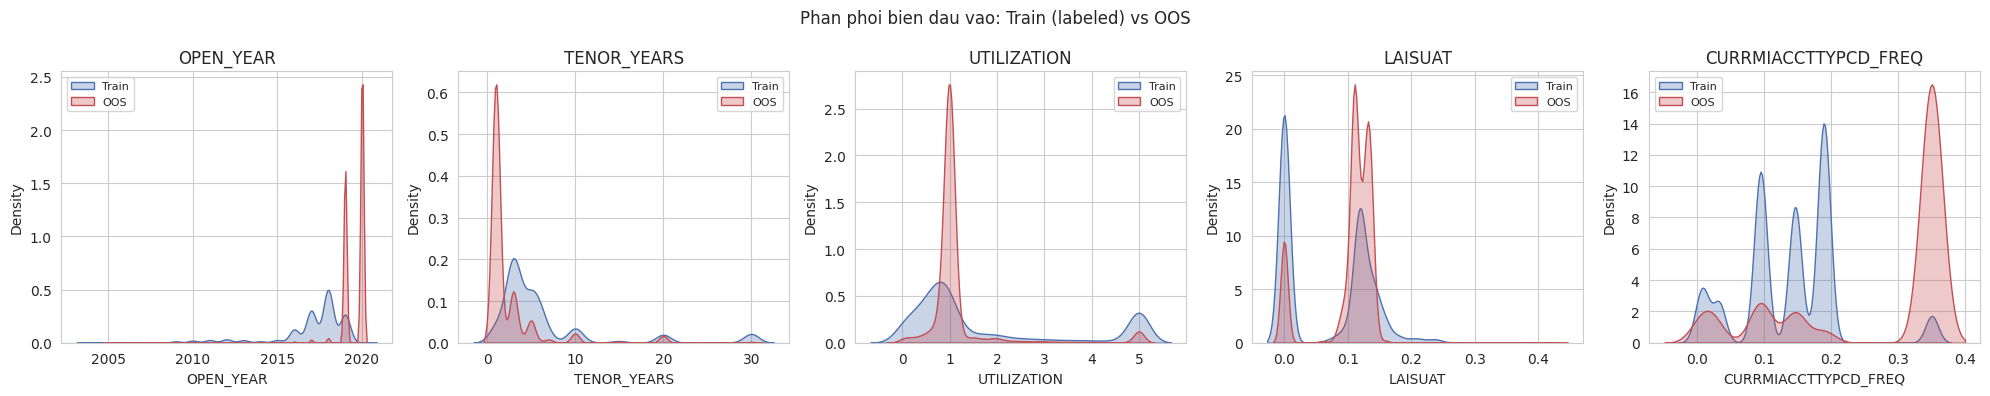

In [46]:
shift_cols = ["OPEN_YEAR", "TENOR_YEARS", "UTILIZATION", "LAISUAT", "CURRMIACCTTYPCD_FREQ"]
fig, axes = plt.subplots(1, len(shift_cols), figsize=(4 * len(shift_cols), 4))
for ax, col in zip(axes, shift_cols):
    sns.kdeplot(df_full[col], ax=ax, label="Train", fill=True, alpha=0.3, color="#4C72B0")
    sns.kdeplot(df_oos[col], ax=ax, label="OOS", fill=True, alpha=0.3, color="#C44E52")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Phan phoi bien dau vao: Train (labeled) vs OOS")
plt.tight_layout()
plt.show()

In [47]:
print("Co cau san pham (MJACCTTYPCD) Train vs OOS (%):")
pd.DataFrame({
    "train_pct": (df_full["MJACCTTYPCD"].value_counts(normalize=True) * 100).round(1),
    "oos_pct": (df_oos["MJACCTTYPCD"].value_counts(normalize=True) * 100).round(1),
})

Co cau san pham (MJACCTTYPCD) Train vs OOS (%):


,train_pct,oos_pct
MJACCTTYPCD,,
CML,8.2,21.1
CNS,82.5,32.9
MTG,9.3,46.0


## 8. Giải thích mô hình: Top 10 biến quan trọng nhất (SHAP)


In [48]:
print("Giai thich mo hinh:", PRODUCTION_MODEL)
explainer = shap.TreeExplainer(final_model_A)

# Lay mau 3000 dong de tinh SHAP nhanh hon (khong can toan bo du lieu de uoc luong on dinh)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_full.shape[0], size=min(3000, X_full.shape[0]), replace=False)
X_sample = X_full[sample_idx]
X_sample = X_sample.toarray() if hasattr(X_sample, "toarray") else X_sample

shap_values = explainer.shap_values(X_sample)
feat_names = preprocess_final.get_feature_names_out()
print("Da tinh xong SHAP values, shape:", np.array(shap_values).shape)

Giai thich mo hinh: XGBoost
Da tinh xong SHAP values, shape: (3000, 45, 5)


In [49]:
if isinstance(shap_values, list):
    mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    mean_abs = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs = np.abs(shap_values).mean(axis=0)

top10 = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False).head(10)
top10

,0
num__OPEN_YEAR,0.963925
num__UTILIZATION,0.925560
num__TENOR_YEARS,0.865826
num__LOG_CURR_BAL,0.607129
num__ORGNBR_FREQ,0.486510
num__LOG_BASE_BAL,0.411838
num__LAISUAT,0.406294
num__CURRMIACCTTYPCD_FREQ,0.386292
num__PARENTORGNBR_FREQ,0.377478
num__MUCDICHVAY_FREQ,0.130973


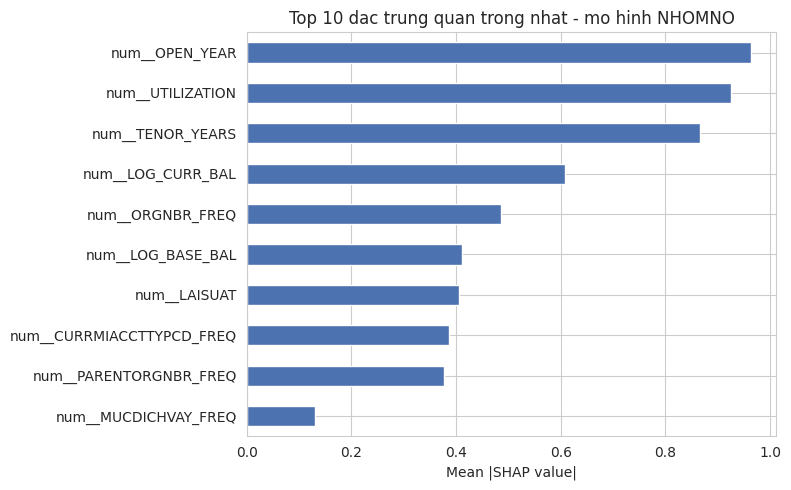

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
top10.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 10 dac trung quan trong nhat - mo hinh NHOMNO")
plt.tight_layout()
plt.show()

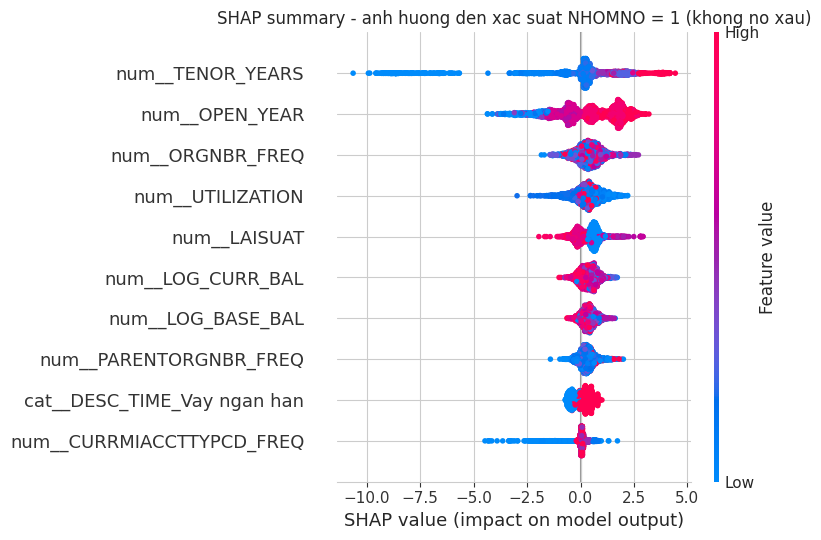

In [51]:
sv_for_plot = shap_values[0] if isinstance(shap_values, list) else (
    shap_values[:, :, 0] if shap_values.ndim == 3 else shap_values)
shap.summary_plot(sv_for_plot, X_sample, feature_names=feat_names, show=False, max_display=10)
plt.title("SHAP summary - anh huong den xac suat NHOMNO = 1 (khong no xau)")
plt.tight_layout()
plt.show()